In [1]:
import sys
sys.path.insert(0, "/global/cfs/cdirs/desicollab/users/bautista/bgs/desi_pv_mocks")


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits

from desi_pv_mocks.config import load_config 
cfg=load_config('../config_files/mock_config_v3.0.yaml')

cosmo = FlatLambdaCDM(H0=100., Om0=0.3151)

In [46]:
print(cfg.data_fp_clus_data)
d_data = fits.open(cfg.data_fp_clus_data)[1].data
d_rand = fits.open(cfg.data_fp_clus_rand)[1].data
print(d_data.names)
print(d_rand.names)
print(d_data.size, d_rand.size)
print(d_rand.size/d_data.size)


/global/cfs/cdirs/desi/science/td/pv/fpgalaxies/Y3/v1/FP_clustering_data_v1.fits
['TARGETID', 'RA', 'DEC', 'Z', 'ZCMB', 'WEIGHT', 'NPV', 'NDENS', 'LOGDIST', 'LOGDIST_ERR']
['RA', 'DEC', 'Z', 'ZCMB', 'WEIGHT', 'NPV', 'NDENS', 'MU_ERR', 'LOGDIST_ERR', 'PV_ERR']
159187 3183740
20.0


In [48]:
m_data = fits.open(cfg.mock_fp_clus_data.format(phase=0, real=0))[1].data
m_rand = fits.open(cfg.mock_fp_clus_rand.format(phase=0))[1].data
print(m_data.names)
print(m_rand.names)
print(m_data.size, m_rand.size)
print(m_rand.size/m_data.size)


['RA', 'DEC', 'Z', 'NPV', 'LOGDIST', 'LOGDIST_ERR', 'LOGDIST_TRUE', 'PV', 'PV_ERR', 'PV_TRUE']
['RA', 'DEC', 'Z', 'WEIGHT', 'NPV', 'LOGDIST_ERR', 'PV_ERR']
170263 4115779
24.173067548439768


NPV


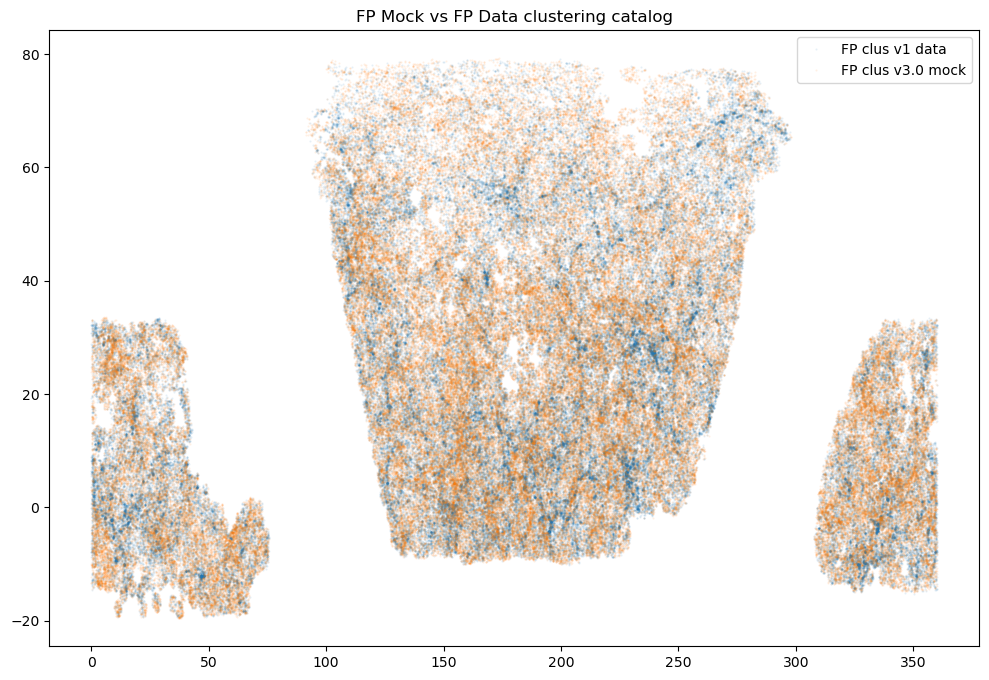

In [9]:
plt.figure(figsize=(12, 8))
plt.plot(d_data['RA'], d_data['DEC'], '.', ms=1, alpha=0.1, label=f'FP clus {cfg.data_fp_full_version} data')
plt.plot(m_data['RA'], m_data['DEC'], '.', ms=1, alpha=0.1, label=f'FP clus {cfg.version_fp_full} mock')
plt.title('FP Mock vs FP Data clustering catalog')
plt.legend()

Text(0, 0.5, 'Dec [deg]')

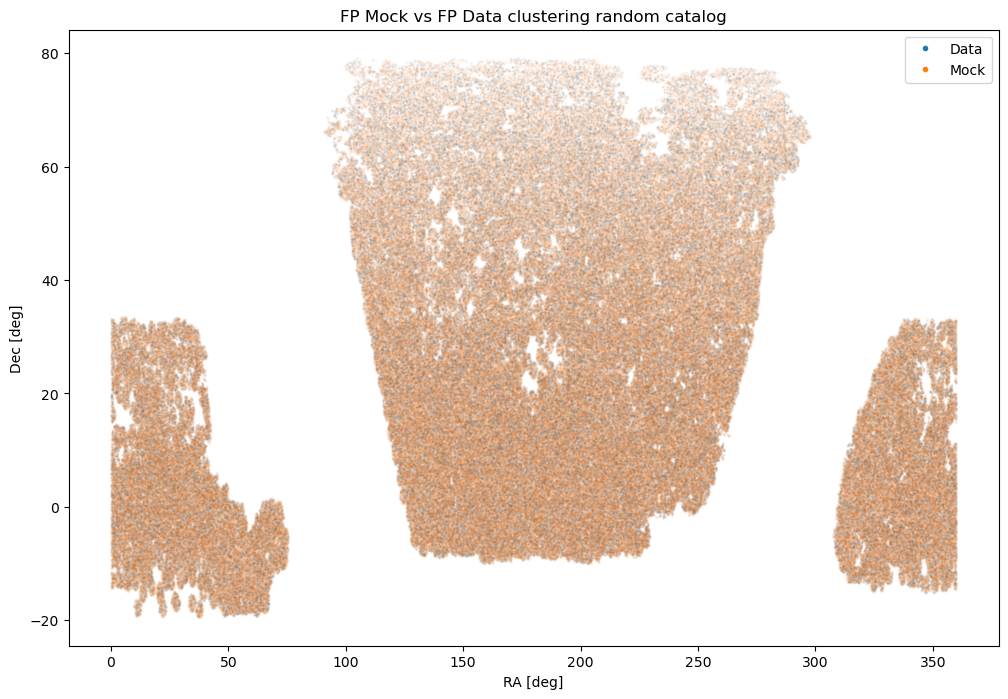

In [10]:
plt.figure(figsize=(12, 8))
plt.plot(d_rand['RA'][::20], d_rand['DEC'][::20], '.', ms=1, alpha=0.1)
plt.plot(m_rand['RA'][::20], m_rand['DEC'][::20], '.', ms=0.5, alpha=0.1)
plt.plot([], [], 'C0.', label='Data')
plt.plot([], [], 'C1.', label='Mock')
plt.title('FP Mock vs FP Data clustering random catalog')
plt.legend()
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]') 

0


Text(0.5, 0, 'Redshift')

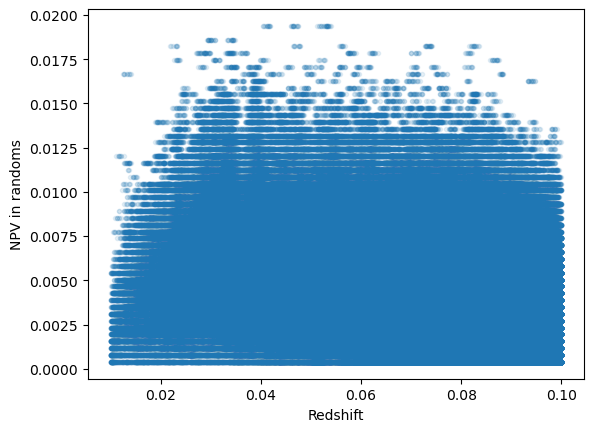

In [49]:
for phase in range(1):
    for real in range(1):
        m_data_temp = fits.open(cfg.mock_fp_clus_rand.format(phase=phase, real=real))[1].data
        w = m_data_temp['NPV']!=0
        plt.plot(m_data_temp['Z'][w], m_data_temp['NPV'][w], 'C0.', alpha=0.1) 
        print(np.sum(~w))
plt.ylabel('NPV in randoms')
plt.xlabel("Redshift")

0


Text(0.5, 0, 'Redshift')

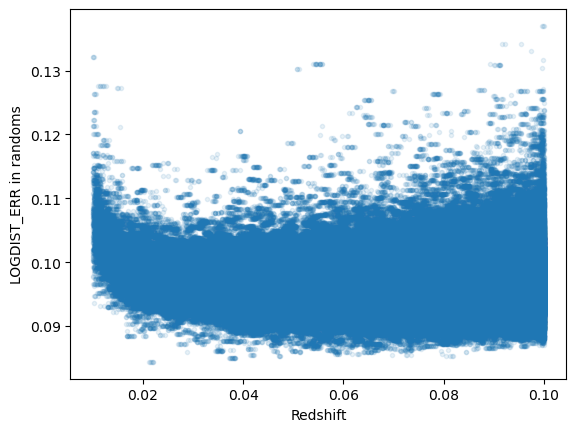

In [52]:
for phase in range(1, 2):
    for real in range(1):
        m_data_temp = fits.open(cfg.mock_fp_clus_rand.format(phase=phase))[1].data
        w = m_data_temp['LOGDIST_ERR']!=0
        plt.plot(m_data_temp['Z'][w], m_data_temp['LOGDIST_ERR'][w], 'C0.', alpha=0.1) 
        print(np.sum(~w))
#plt.ylim(0, 0.2)
plt.ylabel('LOGDIST_ERR in randoms')
plt.xlabel("Redshift")

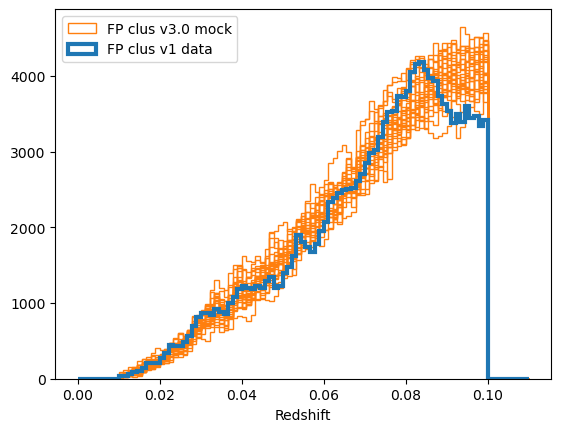

In [11]:
zbins = np.linspace(0, 0.11, 100)
for phase in range(1):
    for real in range(cfg.n_reals):
        m_data_temp = fits.open(cfg.mock_fp_clus_data.format(phase=phase, real=real))[1].data
        label = f'FP clus {cfg.version_fp_full} mock' if phase == 0 and real ==0 else None 
        _=plt.hist(m_data_temp['Z'], color='C1', bins=zbins, histtype='step', alpha=1, label=label)

_=plt.hist(d_data['Z'], bins=zbins, histtype='step', lw=3,
           label=f'FP clus {cfg.data_fp_full_version} data')

plt.xlabel('Redshift')
plt.legend()

In [12]:
area_ngc = 8500.3589 # sq deg
area_sgc = 3610.6785 # sq deg

area_tot = area_ngc + area_sgc # sq deg

zbins = np.linspace(0, 0.11, 100)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=area_tot):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz/zvol/area


In [54]:
m_nzs = []
for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(cfg.mock_fp_clus_data.format(phase=phase, real=real))[1].data
        m_nz = get_nz(m_data_temp['Z'], area=area_tot)
        m_nzs.append(m_nz)
m_nzs = np.array(m_nzs) 
print(m_nzs.shape)

(27, 99)


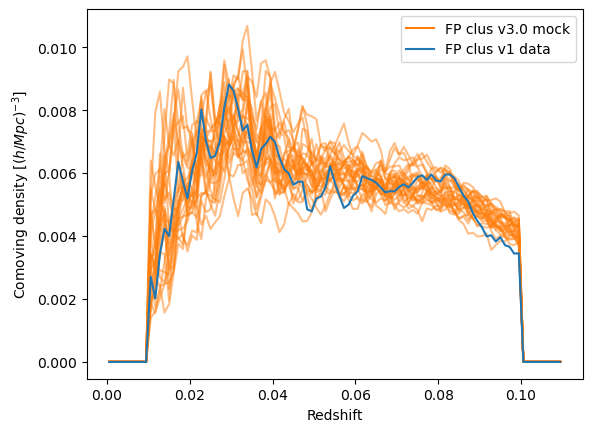

In [55]:
for m_nz in m_nzs:      
    plt.plot(zcen, m_nz, 'C1-', alpha=0.5)
plt.plot([], [], 'C1-', label=f'FP clus {cfg.version_fp_full} mock')

#d_nz = get_nz(d_data['Z'], weights=d_data['WEIGHT'], area=area_tot)
d_nz = get_nz(d_data['Z'], area=area_tot)
plt.plot(zcen, d_nz, 'C0-', label=f'FP clus {cfg.data_fp_full_version} data')

plt.ylabel('Comoving density [${(h/Mpc)}^{-3}$]')
plt.xlabel('Redshift')
plt.legend()
plt.savefig(f'../plots/nz_FP_clus_mock_{cfg.version_fp_clus}_data_{cfg.data_fp_full_version}.pdf')

In [21]:
m_pv = {'counts': [], 'mean': [], 'std': []} 
for phase in range(1):
    for real in range(27):
        m_data_temp = fits.open(cfg.mock_fp_clus_data.format(phase=phase, real=real))[1].data
        pv_mean, _ = np.histogram(m_data_temp['Z'], bins=zbins, weights=m_data_temp['PV_TRUE'])
        pv_var, _ = np.histogram(m_data_temp['Z'], bins=zbins, weights=m_data_temp['PV_TRUE']**2)
        pv_counts, _ = np.histogram(m_data_temp['Z'], bins=zbins) 
        m_pv['counts'].append(pv_counts) 
        m_pv['mean'].append(pv_mean/pv_counts) 
        m_pv['std'].append(np.sqrt(pv_var/pv_counts - (pv_mean/pv_counts)**2)) 




/tmp/ipykernel_1119557/2125436901.py:9: RuntimeWarning: invalid value encountered in divide
  m_pv['mean'].append(pv_mean/pv_counts)
/tmp/ipykernel_1119557/2125436901.py:10: RuntimeWarning: invalid value encountered in divide
  m_pv['std'].append(np.sqrt(pv_var/pv_counts - (pv_mean/pv_counts)**2))


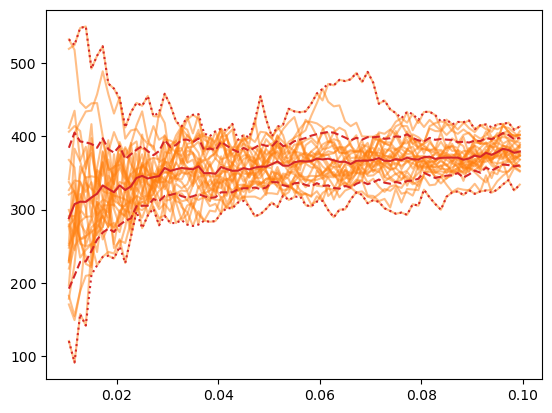

In [22]:
for real in range(27):
    plt.plot(zcen, m_pv['std'][real], 'C1-', alpha=0.5)

m_pv_std_mean = np.mean(np.array(m_pv['std']), axis=0)
m_pv_std_std = np.std(np.array(m_pv['std']), axis=0)
m_pv_std_max = np.max(np.array(m_pv['std']), axis=0)
m_pv_std_min = np.min(np.array(m_pv['std']), axis=0)
plt.plot(zcen, m_pv_std_mean, 'C3-', label=f'FP clustering mocks {cfg.version_fp_clus}')
plt.plot(zcen, m_pv_std_max, 'C3:')
plt.plot(zcen, m_pv_std_min, 'C3:')
plt.plot(zcen, m_pv_std_mean+m_pv_std_std, 'C3--')
plt.plot(zcen, m_pv_std_mean-m_pv_std_std, 'C3--')

In [48]:
mb_pv = {'counts': [], 'mean': [], 'std': []} 
for phase in range(1):
    for real in range(27):
        m_data_temp = h5py.File(cfg.mock_bgs_base_data.format(phase=phase, real=real), 'r')
        zobs = m_data_temp['zobs'][...] 
        zcos = m_data_temp['zcos'][...] 
        pv = cfg.light_speed*(( 1 + zobs)/(1+zcos) - 1)  
        m_data_temp.close()
        pv_mean, _ = np.histogram(zobs, bins=zbins, weights=pv)
        pv_var, _ = np.histogram(zobs, bins=zbins, weights=pv**2)
        pv_counts, _ = np.histogram(zobs, bins=zbins) 
        mb_pv['counts'].append(pv_counts) 
        mb_pv['mean'].append(pv_mean/pv_counts) 
        mb_pv['std'].append(np.sqrt(pv_var/pv_counts - (pv_mean/pv_counts)**2)) 


<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1755152/3087589257.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_v$ [km/s]')


Text(0, 0.5, '$\\sigma_v$ [km/s]')

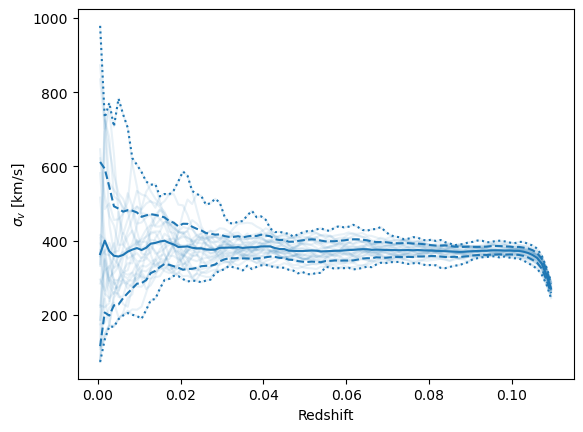

In [49]:
for real in range(27):
    plt.plot(zcen, mb_pv['std'][real], 'C0-', alpha=0.1)

mb_pv_std_mean = np.mean(np.array(mb_pv['std']), axis=0)
mb_pv_std_std = np.std(np.array(mb_pv['std']), axis=0)
mb_pv_std_max = np.max(np.array(mb_pv['std']), axis=0)
mb_pv_std_min = np.min(np.array(mb_pv['std']), axis=0)
plt.plot(zcen, mb_pv_std_mean, 'C0-')
plt.plot(zcen, mb_pv_std_max, 'C0:')
plt.plot(zcen, mb_pv_std_min, 'C0:')
plt.plot(zcen, mb_pv_std_mean+mb_pv_std_std, 'C0--')
plt.plot(zcen, mb_pv_std_mean-mb_pv_std_std, 'C0--')
plt.xlabel('Redshift')
plt.ylabel('$\sigma_v$ [km/s]') 

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1755152/30333309.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$\sigma_v$ [km/s]')


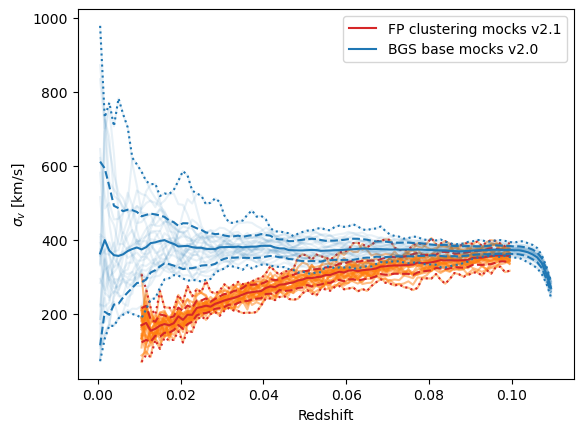

In [50]:
for real in range(27):
    plt.plot(zcen, m_pv['std'][real], 'C1-', alpha=0.5)

m_pv_std_mean = np.mean(np.array(m_pv['std']), axis=0)
m_pv_std_std = np.std(np.array(m_pv['std']), axis=0)
m_pv_std_max = np.max(np.array(m_pv['std']), axis=0)
m_pv_std_min = np.min(np.array(m_pv['std']), axis=0)
plt.plot(zcen, m_pv_std_mean, 'C3-', label=f'FP clustering mocks {cfg.version_fp_clus}')
plt.plot(zcen, m_pv_std_max, 'C3:')
plt.plot(zcen, m_pv_std_min, 'C3:')
plt.plot(zcen, m_pv_std_mean+m_pv_std_std, 'C3--')
plt.plot(zcen, m_pv_std_mean-m_pv_std_std, 'C3--')

for real in range(27):
    plt.plot(zcen, mb_pv['std'][real], 'C0-', alpha=0.1)
plt.plot(zcen, mb_pv_std_mean, 'C0-', label=f'BGS base mocks {cfg.version_bgs_base}')
plt.plot(zcen, mb_pv_std_max, 'C0:')
plt.plot(zcen, mb_pv_std_min, 'C0:')
plt.plot(zcen, mb_pv_std_mean+mb_pv_std_std, 'C0--')
plt.plot(zcen, mb_pv_std_mean-mb_pv_std_std, 'C0--')
    
plt.xlabel('Redshift')
plt.ylabel('$\sigma_v$ [km/s]') 
plt.legend()